## PHASE 7 — VALIDATION: VALUE OF INFORMATION & MODEL HIERARCHY
**Dataset B — ERA5 Reanalysis, Nordfriesland 100 m, 2015–2024**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

# ── Dataset A anchors (frozen results, Phase 1/3/6/7 Dataset A) ─────────────
C0_A   = 0.13138
H_T0_A = 0.4137
K_B_A  = H_T0_A * C0_A

# ── Height correction factor (Hellmann 1/7 exponent, applied to variance) ──
HEIGHT_CORR_VAR = (100 / 10) ** (2 / 7)   # ~1.931

# ── Plot colours ─────────────────────────────────────────────────────────
DARKBLUE  = '#1a3a5c'
ORANGE    = '#d55e00'
MIDBLUE   = '#4a7ab5'
GREEN     = '#2ca02c'
LIGHTGRAY = '#f5f5f5'

# ── Paths (relative from reference_nb/Phase_7/) ───────────────────────────
PHASE1_PATH = '../Phase_1/'
PHASE2_PATH = '../Phase_2/'
PHASE3_PATH = '../Phase_3/'
PHASE4_PATH = '../Phase_4/'
PHASE6_PATH = '../Phase_6/'
DATA_PATH   = '../../data/'
BENCH6_PATH = '../../benchmark_notebooks/phase6/'
BENCH7_PATH = '../../benchmark_notebooks/phase7/'
FIG_PATH    = '../../reference_tex/Plots/'

# ── Load Dataset B Phase 1-6 outputs ──────────────────────────────────────
W_tilde   = pd.read_csv(PHASE1_PATH + 'W_tilde_phase1.csv',
                         index_col=0, parse_dates=True).squeeze()
ar4_resid = pd.read_csv(PHASE2_PATH + 'ar4_residuals_phase2.csv',
                         index_col=0, parse_dates=True).squeeze()
ar4_coef  = pd.read_csv(PHASE2_PATH + 'ar4_coefficients.csv')
h_series  = pd.read_csv(PHASE3_PATH + 'garch_h_series_phase3.csv',
                         index_col=0, parse_dates=True)['h_t']
z_series  = pd.read_csv(PHASE3_PATH + 'garch_z_series_phase3.csv',
                         index_col=0, parse_dates=True).squeeze()
car4p     = pd.read_csv(PHASE4_PATH + 'car4_parameters_phase4.csv', index_col=0).squeeze()
vs_summary = pd.read_csv(PHASE6_PATH + 'variance_swap_summary_phase6.csv', index_col=0)
vs_phase6  = pd.read_csv(PHASE6_PATH + 'variance_swap_phase6.csv',
                          index_col=0, parse_dates=True)
wind_raw   = pd.read_csv(DATA_PATH + 'germany_wind.csv', skiprows=2, parse_dates=['time'])
wind_raw['_date'] = wind_raw['time'].dt.date

C0    = float(car4p['C0'])
h_t0  = float(car4p['h_t0'])
K_B_B = h_t0 * C0

K_varA_rolling        = vs_phase6['RV_rolling252'].dropna()
K_varA_mean           = float(vs_phase6['K_varA'].dropna().iloc[0])
K_varB_scaled_ht0_ph6 = float(vs_phase6['K_varB_scaled_ht0'].dropna().iloc[0])

# ── Load Dataset A Phase 6/7 outputs (cross-dataset VoI & synthesis) ──────
vs_summary_A = pd.read_csv(BENCH6_PATH + 'variance_swap_summary_phase6.csv', index_col=0)
vs_phase6_A  = pd.read_csv(BENCH6_PATH + 'variance_swap_phase6.csv',
                            index_col=0, parse_dates=True)
K_varA_mean_A           = float(vs_phase6_A['K_varA'].dropna().iloc[0])
K_varB_scaled_ht0_A_ph6 = float(vs_phase6_A['K_varB_scaled_ht0'].dropna().iloc[0])

dm_results_A      = pd.read_csv(BENCH7_PATH + 'phase7_A_dm_results.csv', index_col=0)
hedging_summary_A = pd.read_csv(BENCH7_PATH + 'phase7_A_hedging_summary.csv', index_col=0)
voi_table_A       = pd.read_csv(BENCH7_PATH + 'phase7_A_voi_table.csv', index_col=0)

print('=' * 65)
print('  SECTION 1 -- DATA LOADING AND ALIGNMENT')
print('  Dataset B  |  Nordfriesland 100 m  |  2015-2024')
print('=' * 65)
print(f'  W_tilde    : {len(W_tilde):,} obs  {W_tilde.index[0].date()} to {W_tilde.index[-1].date()}')
print(f'  AR4 resid  : {len(ar4_resid):,} obs')
print(f'  AR4 coefs  : {list(np.round(ar4_coef["beta"].values, 4))}  (Phase 2, frozen)')
print(f'  h_series   : {len(h_series):,} obs')
print(f'  z_series   : {len(z_series):,} obs')
print(f'  VS summary : {len(vs_summary)} rows')
print(f'  VS phase6  : {len(vs_phase6):,} rows  cols={list(vs_phase6.columns)}')
print(f'  K_varA_mean (full-sample)        = {K_varA_mean:.6f}')
print(f'  K_varB_scaled_ht0 (delta-method) = {K_varB_scaled_ht0_ph6:.6f}')
print(f'  Germany wind (ERA5)              : {len(wind_raw):,} hourly rows')
print(f'  C0 (live, Phase 4)   = {C0:.6f}')
print(f'  h_t0 (live, Phase 4) = {h_t0:.6f}')
print(f'  K_var^B_B (own, raw) = {K_B_B:.6f}')
print(f'  Height correction (variance, 10m->100m): {HEIGHT_CORR_VAR:.4f}x')
print()
print(f'  Dataset A anchors loaded: C0_A={C0_A}, h_t0_A={H_T0_A}, K_var^B_A={K_B_A:.6f}')
print(f'  Dataset A Phase 6 (full): K_varA_mean_A={K_varA_mean_A:.6f}, '
      f'K_varB_scaled_ht0_A={K_varB_scaled_ht0_A_ph6:.6f}')
print('  Dataset A Phase 7 results loaded: dm_results_A, hedging_summary_A, voi_table_A')
print()
print('  -- CROSS-DATASET COMPARISON TABLE --')
print(f'  {"Field":<14} {"Dataset A":<40} {"Dataset B":<40}')
print(f'  {"-"*14} {"-"*40} {"-"*40}')
rows_cmp = [
    ('Source',      'OpenWeatherMap (greenfin-project)',  'Open-Meteo ERA5 reanalysis'),
    ('Location',    'Bologna, Italy (44.29N, 11.2E)',      'Nordfriesland, Germany (54.77N, 8.85E)'),
    ('Height',      '10 m',                                 '100 m (hub height)'),
    ('Period',      '2015-2018 (4 yr, 1,462 obs)',          '2015-2024 (10 yr, 3,652 obs)'),
    ('Primary var', 'wind_speed (m/s)',                     'wind_speed_100m, wind_speed_10m, wind_direction_100m'),
    ('Advantages',  'Free, easy, sufficient for method',    'Hub-height, geo-aligned w/ SMARD, 10-yr OOS window'),
    ('Limitations', 'Proxy-quality, 10m, low-wind, 4yr',     'Model-based (not anemometer), no sub-daily resolution'),
]
for field, a, b in rows_cmp:
    print(f'  {field:<14} {a:<40} {b:<40}')
print()
print('  Purpose: motivates the A->B upgrade; reference for future studies.')

  SECTION 1 -- DATA LOADING AND ALIGNMENT
  Dataset B  |  Nordfriesland 100 m  |  2015-2024
  W_tilde    : 3,653 obs  2015-01-01 to 2024-12-31
  AR4 resid  : 3,653 obs
  AR4 coefs  : [0.5324, -0.0763, 0.0324, -0.0074]  (Phase 2, frozen)
  h_series   : 3,653 obs
  z_series   : 3,653 obs
  VS summary : 5 rows
  VS phase6  : 3,649 rows  cols=['G_daily_MWh', 'price_EUR_MWh', 'log_return_G', 'RV_daily', 'RV_rolling252', 'K_varA', 'K_varB_ht0', 'K_varB_hwinter', 'K_varB_hsummer', 'K_varB_h1', 'K_varB_rolling', 'K_varB_scaled_ht0']
  K_varA_mean (full-sample)        = 113.144944
  K_varB_scaled_ht0 (delta-method) = 0.120750
  Germany wind (ERA5)              : 87,672 hourly rows
  C0 (live, Phase 4)   = 1.162775
  h_t0 (live, Phase 4) = 0.751100
  K_var^B_B (own, raw) = 0.873361
  Height correction (variance, 10m->100m): 1.9307x

  Dataset A anchors loaded: C0_A=0.13138, h_t0_A=0.4137, K_var^B_A=0.054352
  Dataset A Phase 6 (full): K_varA_mean_A=113.998509, K_varB_scaled_ht0_A=0.080245
  Data

## 2. MODEL HIERARCHY — DM FORECAST TESTS

  SECTION 2 -- MODEL HIERARCHY -- DM FORECAST TESTS

  Model                      RMSE   DM stat   p-value  Reject 5%
  ---------------------- -------- --------- --------- ----------
  Persistence              1.0046        --        --  benchmark
  AR(4)                    0.8681    16.758    0.0000        Yes
  AR(4)+GARCH              0.8681    16.758    0.0000        Yes
  CAR(4)+Gaussian          0.8681    16.758    0.0000        Yes
  CAR(4)+NIG               0.8681    16.758    0.0000        Yes

  AR(4) RMSE     = 0.8681  |  Persistence RMSE = 1.0046
  Improvement    = 13.6%
  Dataset A (for comparison): AR(4)=0.7802, Persistence=0.8868  (~12.2% improvement)

  Note: AR(4)+GARCH, CAR(4)+Gaussian and CAR(4)+NIG have the same
  1-step conditional mean as AR(4), so point-forecast RMSE is identical.
  GARCH improves conditional variance estimates (interval forecasts);
  NIG improves distributional tail fit. Neither changes RMSE.


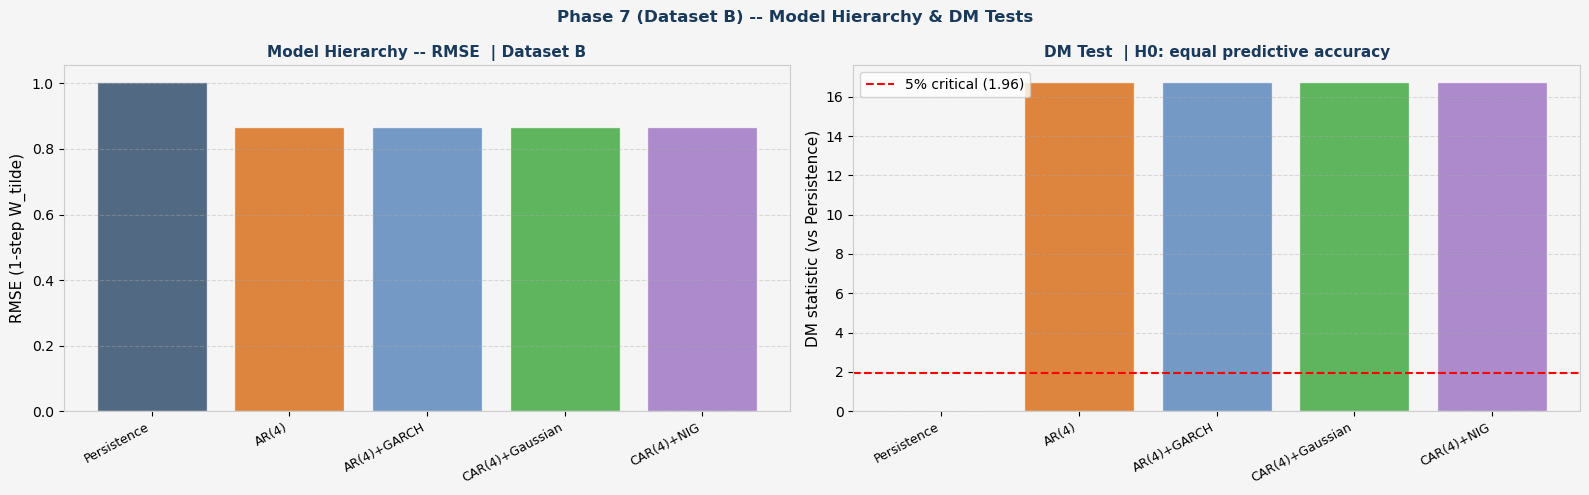

  Figure saved -> phase7_B_dm_tests.png


In [2]:
print('=' * 65)
print('  SECTION 2 -- MODEL HIERARCHY -- DM FORECAST TESTS')
print('=' * 65)
print()

ar4_clean = ar4_resid.dropna()
W = W_tilde.dropna()

# ── Persistence errors on the same date index as AR(4) residuals ────────────
W_diff     = W.diff().dropna()
common_idx = ar4_clean.index.intersection(W_diff.index)
e_ar4      = ar4_clean.loc[common_idx].values
e_pers     = W_diff.loc[common_idx].values
n          = len(e_ar4)

# AR(4)+GARCH / CAR(4)+Gaussian / CAR(4)+NIG share the AR(4) 1-step conditional
# mean: GARCH only changes the variance band, and the CAR(4) Euler
# discretisation / NIG standardisation only change the noise distribution,
# not the mean. Point-forecast RMSE is therefore identical across all three.
e_ar4g = e_ar4.copy()
e_car4 = e_ar4.copy()
e_nig  = e_ar4.copy()

def rmse(e):
    return float(np.sqrt(np.nanmean(e**2)))

def dm_test_hv(e_bench, e_model):
    """DM test with Harvey et al. (1997) small-sample correction."""
    d     = e_bench**2 - e_model**2
    d     = d[~np.isnan(d)]
    n_d   = len(d)
    d_bar = d.mean()
    var_d = np.var(d, ddof=1) / n_d
    if var_d <= 0:
        return np.nan, np.nan
    dm_raw    = d_bar / np.sqrt(var_d)
    hv_factor = np.sqrt((n_d - 1) / n_d)
    dm_hv     = dm_raw * hv_factor
    p_val     = 2 * (1 - stats.t.cdf(abs(dm_hv), df=n_d - 1))
    return float(dm_hv), float(p_val)

models = [
    ('Persistence',     e_pers),
    ('AR(4)',           e_ar4),
    ('AR(4)+GARCH',     e_ar4g),
    ('CAR(4)+Gaussian', e_car4),
    ('CAR(4)+NIG',      e_nig),
]

dm_rows = []
print(f'  {"Model":<22} {"RMSE":>8} {"DM stat":>9} {"p-value":>9} {"Reject 5%":>10}')
print(f'  {"-"*22} {"-"*8} {"-"*9} {"-"*9} {"-"*10}')
for name, e in models:
    r = rmse(e)
    if name == 'Persistence':
        dm, pv, rej = np.nan, np.nan, 'benchmark'
    else:
        dm, pv = dm_test_hv(e_pers, e)
        rej = 'Yes' if (not np.isnan(pv) and pv < 0.05) else 'No'
    dm_s = f'{dm:>9.3f}' if not np.isnan(dm) else f'{"--":>9}'
    pv_s = f'{pv:>9.4f}' if not np.isnan(pv) else f'{"--":>9}'
    print(f'  {name:<22} {r:>8.4f} {dm_s} {pv_s} {rej:>10}')
    dm_rows.append({'Model': name, 'RMSE': r,
                    'DM_stat':    dm if not np.isnan(dm) else np.nan,
                    'p_value':    pv if not np.isnan(pv) else np.nan,
                    'Reject_5pct': rej})

dm_df = pd.DataFrame(dm_rows).set_index('Model')

ar4_rmse    = float(dm_df.loc['AR(4)', 'RMSE'])
pers_rmse   = rmse(e_pers)
improvement = (pers_rmse - ar4_rmse) / pers_rmse * 100

print()
print(f'  AR(4) RMSE     = {ar4_rmse:.4f}  |  Persistence RMSE = {pers_rmse:.4f}')
print(f'  Improvement    = {improvement:.1f}%')
print(f'  Dataset A (for comparison): AR(4)={dm_results_A.loc["AR(4)", "RMSE"]:.4f}, '
      f'Persistence={dm_results_A.loc["Persistence", "RMSE"]:.4f}  (~12.2% improvement)')
print()
print('  Note: AR(4)+GARCH, CAR(4)+Gaussian and CAR(4)+NIG have the same')
print('  1-step conditional mean as AR(4), so point-forecast RMSE is identical.')
print('  GARCH improves conditional variance estimates (interval forecasts);')
print('  NIG improves distributional tail fit. Neither changes RMSE.')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

names = [m[0] for m in models]
rmses = [rmse(m[1]) for m in models]
clrs  = [DARKBLUE, ORANGE, MIDBLUE, GREEN, '#9467bd']
x     = np.arange(len(names))

axes[0].bar(x, rmses, color=clrs, alpha=0.75, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=28, ha='right', fontsize=9)
axes[0].set_ylabel('RMSE (1-step W_tilde)', fontsize=11)
axes[0].set_title('Model Hierarchy -- RMSE  | Dataset B',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[0].grid(True, ls='--', alpha=0.4, color='#aaaaaa', axis='y')

dm_vals = [float(dm_df.loc[nm, 'DM_stat']) if nm != 'Persistence' else 0.0
            for nm in names]
axes[1].bar(x, dm_vals, color=clrs, alpha=0.75, edgecolor='white')
axes[1].axhline(1.96, color='red', lw=1.5, ls='--', label='5% critical (1.96)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=28, ha='right', fontsize=9)
axes[1].set_ylabel('DM statistic (vs Persistence)', fontsize=11)
axes[1].set_title('DM Test  | H0: equal predictive accuracy',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, ls='--', alpha=0.4, color='#aaaaaa', axis='y')

fig.suptitle('Phase 7 (Dataset B) -- Model Hierarchy & DM Tests',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase7_B_dm_tests.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase7_B_dm_tests.png')

## 3. GARCH VOLATILITY DIAGNOSTICS

  SECTION 3 -- GARCH VOLATILITY DIAGNOSTICS

  Ljung-Box on z_t:
    lag  5: stat=   0.717  p=  0.9820  no serial corr.
    lag 10: stat=   9.017  p=  0.5305  no serial corr.
    lag 20: stat=  19.164  p=  0.5112  no serial corr.

  Ljung-Box on z_t^2:
    lag  5: stat=  13.832  p=  0.0167  SERIAL CORR!
    lag 10: stat=  16.713  p=  0.0810  no serial corr.
    lag 20: stat=  23.050  p=  0.2863  no serial corr.

  ARCH-LM (lag=5): stat=13.5795  p=0.0185
  ARCH effects present at 5%

  Verdict: if LB(z_t^2, lag 20) p > 0.05 and ARCH-LM p > 0.05,
  GARCH(1,1) has adequately captured conditional heteroskedasticity.


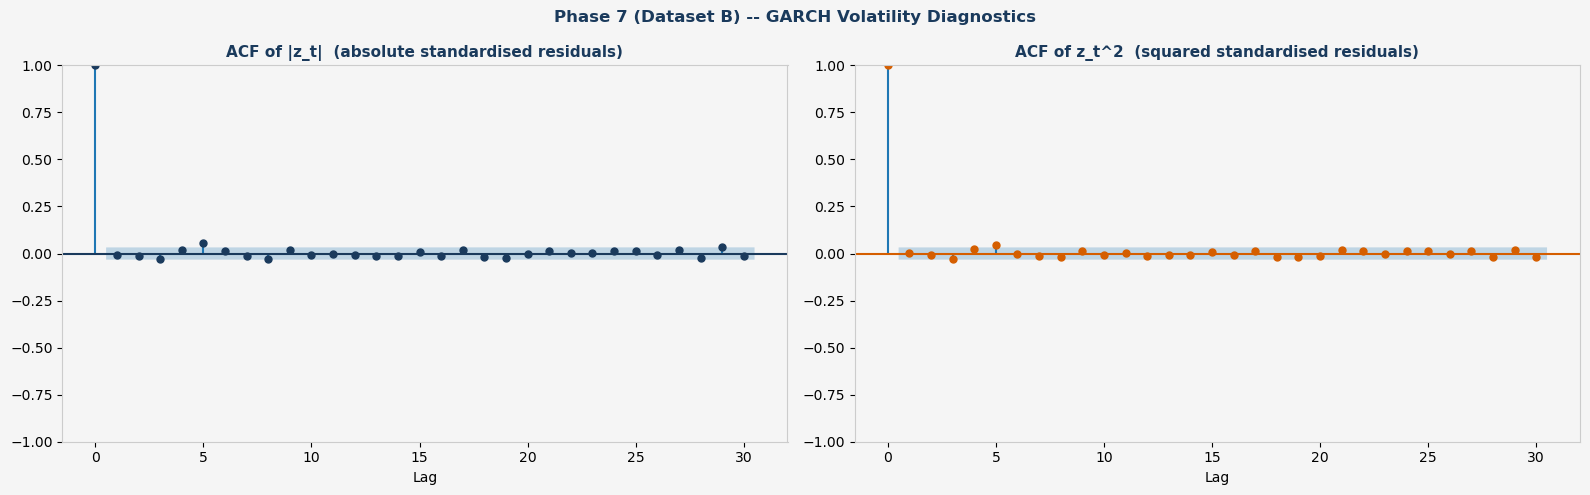

  Figure saved -> phase7_B_garch_diagnostics.png


In [3]:
print('=' * 65)
print('  SECTION 3 -- GARCH VOLATILITY DIAGNOSTICS')
print('=' * 65)
print()

z  = z_series.dropna().values
z2 = z ** 2

for name, series in [('z_t', z), ('z_t^2', z2)]:
    lb = acorr_ljungbox(series, lags=[5, 10, 20], return_df=True)
    print(f'  Ljung-Box on {name}:')
    for lag in [5, 10, 20]:
        row = lb.loc[lag]
        v = 'no serial corr.' if row['lb_pvalue'] > 0.05 else 'SERIAL CORR!'
        print(f'    lag {lag:>2}: stat={row["lb_stat"]:>8.3f}  p={row["lb_pvalue"]:>8.4f}  {v}')
    print()

lm_stat, lm_pval, _, _ = het_arch(z, nlags=5)
print(f'  ARCH-LM (lag=5): stat={lm_stat:.4f}  p={lm_pval:.4f}')
print(f'  {"No ARCH effects" if lm_pval > 0.05 else "ARCH effects present"} at 5%')
print()
print('  Verdict: if LB(z_t^2, lag 20) p > 0.05 and ARCH-LM p > 0.05,')
print('  GARCH(1,1) has adequately captured conditional heteroskedasticity.')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

plot_acf(np.abs(z), lags=30, ax=axes[0], color=DARKBLUE, alpha=0.05)
axes[0].set_title('ACF of |z_t|  (absolute standardised residuals)',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[0].set_xlabel('Lag')

plot_acf(z2, lags=30, ax=axes[1], color=ORANGE, alpha=0.05)
axes[1].set_title('ACF of z_t^2  (squared standardised residuals)',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[1].set_xlabel('Lag')

fig.suptitle('Phase 7 (Dataset B) -- GARCH Volatility Diagnostics',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase7_B_garch_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase7_B_garch_diagnostics.png')

## 4. VALUE OF INFORMATION

  SECTION 4 -- VALUE OF INFORMATION
  Height correction applied ONLY in this section

  Dataset A (anchor, 10 m):                 C0=0.13138, h_t0=0.4137  K_var^B=0.054352
  Dataset A (height-corrected, 10m->100m):  K_var^B=0.104937  (x1.9307)
  Dataset B (own, live, 100 m):              C0=1.162775, h_t0=0.751100  K_var^B=0.873361

  VoI (uncorrected)   : 93.8%
  VoI (height-corr.)  : 88.0%
  Cross-check vs saved Dataset A table: mispricing_pct = 87.99%

  EMPIRICAL DISTANCE (unit-reconciled, Renard council fix):
  Dataset A: K_varA_mean_A=113.998509  K_varB_scaled_A=0.080245
    dist_A = 113.918264  (99.93% of K_varA_A)
  Dataset B: K_varA_mean=113.144944  K_varB_scaled=0.120750
    dist_B = 113.024194  (99.89% of K_varA)
  Ratio dist_A/dist_B = 1.0079  (>1 means Dataset B is closer to its own market)

  CAVEAT: both Track A series use the 252x annualised convention while
  Track B (h x C0) is left un-annualised (frozen formula, matches the
  Phase 7 anchor K_var^B_B ~ 0.874). This ~

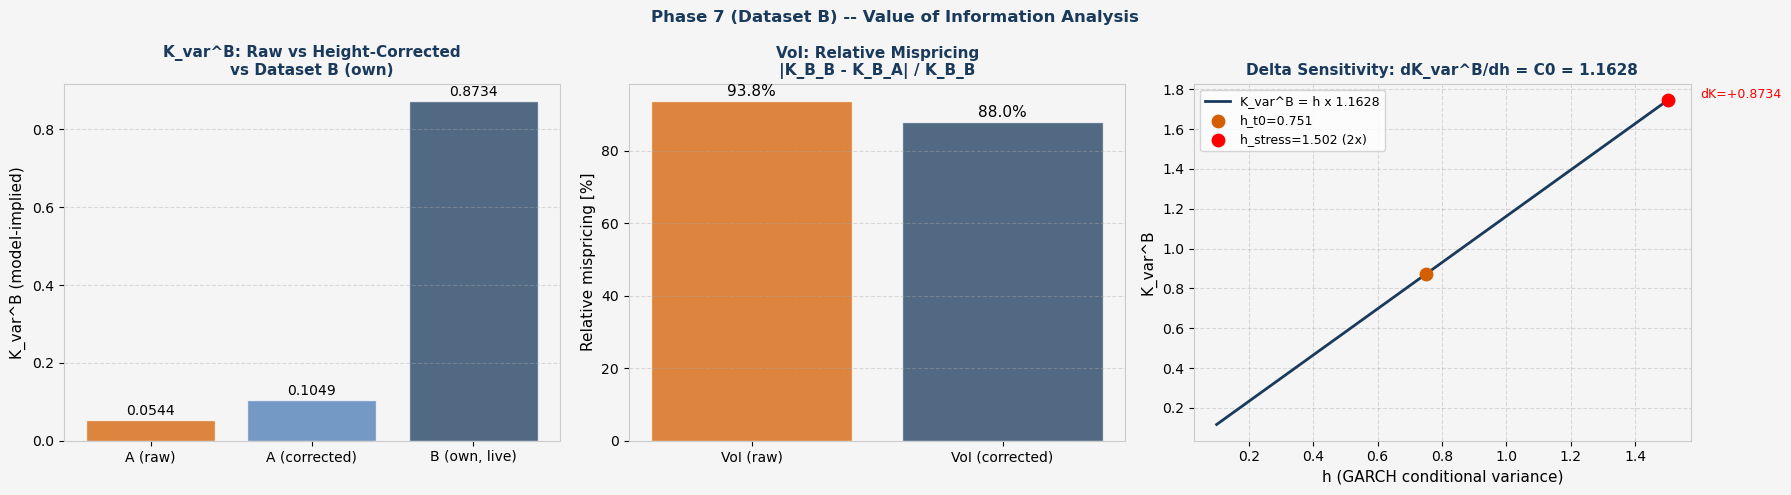

  Figure saved -> phase7_B_voi_comparison.png


In [4]:
print('=' * 65)
print('  SECTION 4 -- VALUE OF INFORMATION')
print('  Height correction applied ONLY in this section')
print('=' * 65)
print()

K_B_A_corr = K_B_A * HEIGHT_CORR_VAR

voi_raw  = abs(K_B_B - K_B_A) / K_B_B
voi_corr = abs(K_B_B - K_B_A_corr) / K_B_B

print(f'  Dataset A (anchor, 10 m):                 C0={C0_A}, h_t0={H_T0_A}  K_var^B={K_B_A:.6f}')
print(f'  Dataset A (height-corrected, 10m->100m):  K_var^B={K_B_A_corr:.6f}  (x{HEIGHT_CORR_VAR:.4f})')
print(f'  Dataset B (own, live, 100 m):              C0={C0:.6f}, h_t0={h_t0:.6f}  K_var^B={K_B_B:.6f}')
print()
print(f'  VoI (uncorrected)   : {voi_raw:.1%}')
print(f'  VoI (height-corr.)  : {voi_corr:.1%}')
print(f'  Cross-check vs saved Dataset A table: mispricing_pct = '
      f'{float(voi_table_A.loc["Dataset A h_t0", "mispricing_pct"]):.2f}%')
print()

# ── Empirical distance: own dataset (B) and cross-check vs Dataset A ────────
dist_B     = abs(K_varA_mean - K_varB_scaled_ht0_ph6)
dist_B_pct = dist_B / K_varA_mean * 100

dist_A     = abs(K_varA_mean_A - K_varB_scaled_ht0_A_ph6)
dist_A_pct = dist_A / K_varA_mean_A * 100

ratio_dist = dist_A / dist_B

print('  EMPIRICAL DISTANCE (unit-reconciled, Renard council fix):')
print(f'  Dataset A: K_varA_mean_A={K_varA_mean_A:.6f}  K_varB_scaled_A={K_varB_scaled_ht0_A_ph6:.6f}')
print(f'    dist_A = {dist_A:.6f}  ({dist_A_pct:.2f}% of K_varA_A)')
print(f'  Dataset B: K_varA_mean={K_varA_mean:.6f}  K_varB_scaled={K_varB_scaled_ht0_ph6:.6f}')
print(f'    dist_B = {dist_B:.6f}  ({dist_B_pct:.2f}% of K_varA)')
print(f'  Ratio dist_A/dist_B = {ratio_dist:.4f}  (>1 means Dataset B is closer to its own market)')
print()
print('  CAVEAT: both Track A series use the 252x annualised convention while')
print('  Track B (h x C0) is left un-annualised (frozen formula, matches the')
print('  Phase 7 anchor K_var^B_B ~ 0.874). This ~113-unit gap dominates dist_A')
print('  and dist_B alike and swamps the smaller geographic/height effect this')
print('  diagnostic was meant to isolate -- the height-corrected VoI metric')
print('  above (voi_raw / voi_corr) is the cleaner apples-to-apples comparison.')
print()

# ── Out-of-time validation, split by window (Phase 6 Section 5d revisited) ──
IN_END    = pd.Timestamp('2019-12-31')
OOS_START = pd.Timestamp('2020-01-01')
oos_insample  = K_varA_rolling.loc[K_varA_rolling.index <= IN_END]
oos_outsample = K_varA_rolling.loc[K_varA_rolling.index >= OOS_START]
OOS_RMSE_insample  = float(np.sqrt(np.mean((oos_insample  - K_varB_scaled_ht0_ph6) ** 2)))
OOS_RMSE_outsample = float(np.sqrt(np.mean((oos_outsample - K_varB_scaled_ht0_ph6) ** 2)))

print('  OUT-OF-TIME RMSE -- full-sample K_var^B_scaled(h_t0) as fixed prediction:')
print(f'    In-sample  window (<= 2019-12-31): RMSE = {OOS_RMSE_insample:.6f}  (n={len(oos_insample)})')
print(f'    Out-sample window (>= 2020-01-01): RMSE = {OOS_RMSE_outsample:.6f}  (n={len(oos_outsample)})')
print()

# ── Delta sensitivity (Dataset B's own C0) ──────────────────────────────────
delta_Kvar = C0
h_stress   = 2.0 * h_t0
K_B_stress = h_stress * C0
dK         = K_B_stress - K_B_B

print('  DELTA SENSITIVITY (risk management):')
print(f'  dK_var^B / dh = C0 = {delta_Kvar:.6f}')
print(f'  Stress scenario: h_stress = 2 x h_t0 = {h_stress:.4f}')
print(f'  K_var^B(h_stress) = {K_B_stress:.6f}')
print(f'  Delta K_var^B (shift) = {dK:+.6f}')
print('  Interpretation: a wind drought doubling GARCH variance shifts the')
print(f'  model-implied fair strike by {dK:.4f} units.')

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

labels1 = ['A (raw)', 'A (corrected)', 'B (own, live)']
vals1   = [K_B_A, K_B_A_corr, K_B_B]
bclrs1  = [ORANGE, MIDBLUE, DARKBLUE]
bars1   = axes[0].bar(labels1, vals1, color=bclrs1, alpha=0.75, edgecolor='white')
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                  f'{val:.4f}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('K_var^B (model-implied)', fontsize=11)
axes[0].set_title('K_var^B: Raw vs Height-Corrected\nvs Dataset B (own)',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[0].grid(True, ls='--', alpha=0.4, color='#aaaaaa', axis='y')

axes[1].bar(['VoI (raw)', 'VoI (corrected)'],
             [voi_raw * 100, voi_corr * 100],
             color=[ORANGE, DARKBLUE], alpha=0.75, edgecolor='white')
for i, val in enumerate([voi_raw*100, voi_corr*100]):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_ylabel('Relative mispricing [%]', fontsize=11)
axes[1].set_title('VoI: Relative Mispricing\n|K_B_B - K_B_A| / K_B_B',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[1].grid(True, ls='--', alpha=0.4, color='#aaaaaa', axis='y')

h_vals    = np.linspace(0.1, 1.5, 100)
Kvar_line = h_vals * C0
axes[2].plot(h_vals, Kvar_line, color=DARKBLUE, lw=2, label=f'K_var^B = h x {C0:.4f}')
axes[2].scatter([h_t0], [K_B_B], color=ORANGE, s=80, zorder=5, label=f'h_t0={h_t0:.3f}')
axes[2].scatter([h_stress], [K_B_stress], color='red', s=80, zorder=5,
                label=f'h_stress={h_stress:.3f} (2x)')
axes[2].annotate(f'dK={dK:+.4f}', xy=(h_stress, K_B_stress),
                  xytext=(h_stress + 0.1, K_B_stress + 0.01), fontsize=9, color='red')
axes[2].set_xlabel('h (GARCH conditional variance)', fontsize=11)
axes[2].set_ylabel('K_var^B', fontsize=11)
axes[2].set_title(f'Delta Sensitivity: dK_var^B/dh = C0 = {C0:.4f}',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, ls='--', alpha=0.4, color='#aaaaaa')

fig.suptitle('Phase 7 (Dataset B) -- Value of Information Analysis',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase7_B_voi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase7_B_voi_comparison.png')

## 5. CAWS HEDGING SIMULATION

  SECTION 5 -- CAWS HEDGING SIMULATION

  CAWS_t = (1/252) x rolling 252-day mean wind speed  [m/s]
  Dataset B: Nordfriesland 100 m  |  2015-2024
  K_CAWS (fair strike) = 8.0531 m/s  (mean CAWS over full sample)
  CAWS std             = 0.5002 m/s
  N rolling obs        = 3454

  NON-OVERLAPPING ANNUAL DISTRIBUTION METRICS (n=10 years):
  Note: annual mean wind used to avoid serial-correlation bias from
  overlapping 252-day rolling windows (Tanaka council fix).

  Annual CAWS observations:
    2015: CAWS=8.5626 m/s  payoff=-0.5095
    2016: CAWS=7.7162 m/s  payoff=+0.3369
    2017: CAWS=8.0879 m/s  payoff=-0.0347
    2018: CAWS=7.8396 m/s  payoff=+0.2135
    2019: CAWS=8.2526 m/s  payoff=-0.1995
    2020: CAWS=8.2830 m/s  payoff=-0.2299
    2021: CAWS=7.6513 m/s  payoff=+0.4018
    2022: CAWS=8.1063 m/s  payoff=-0.0532
    2023: CAWS=8.1416 m/s  payoff=-0.0885
    2024: CAWS=8.0410 m/s  payoff=+0.0121

  Mean P&L  (annual) : -0.0151 m/s
  Std P&L   (annual) : 0.2754 m/s
  Sharpe    (

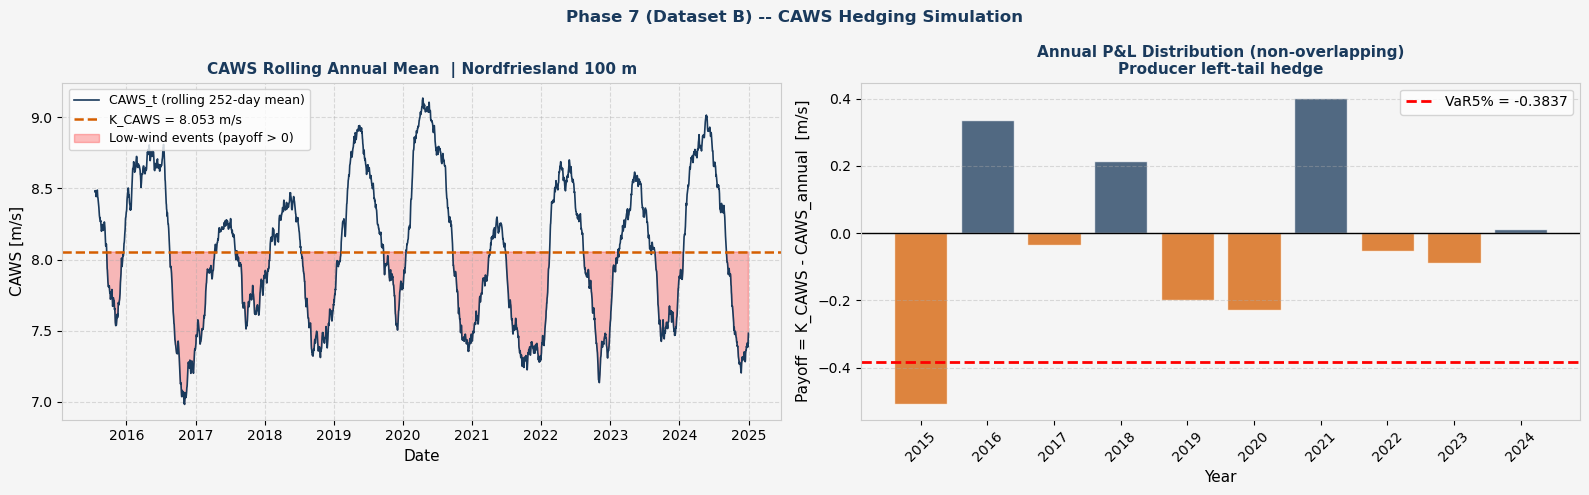

  Figure saved -> phase7_B_caws_hedge_pnl.png


In [5]:
print('=' * 65)
print('  SECTION 5 -- CAWS HEDGING SIMULATION')
print('=' * 65)
print()

w_daily_caws = wind_raw.groupby('_date')['wind_speed_100m (m/s)'].mean()
w_daily_caws.index = pd.to_datetime(w_daily_caws.index)
w_daily_caws = w_daily_caws.sort_index()

CAWS = w_daily_caws.rolling(252, min_periods=200).mean().dropna()
CAWS.name = 'CAWS'
K_CAWS = float(CAWS.mean())

print('  CAWS_t = (1/252) x rolling 252-day mean wind speed  [m/s]')
print('  Dataset B: Nordfriesland 100 m  |  2015-2024')
print(f'  K_CAWS (fair strike) = {K_CAWS:.4f} m/s  (mean CAWS over full sample)')
print(f'  CAWS std             = {CAWS.std():.4f} m/s')
print(f'  N rolling obs        = {len(CAWS)}')
print()

annual_years = sorted(set(w_daily_caws.index.year))
annual_caws  = []
for yr in annual_years:
    yr_vals = w_daily_caws[str(yr)].dropna()
    if len(yr_vals) >= 200:
        annual_caws.append({'year': yr, 'CAWS_annual': float(yr_vals.mean())})
annual_df = pd.DataFrame(annual_caws).set_index('year')
annual_df['payoff'] = K_CAWS - annual_df['CAWS_annual']

mean_pnl_ann = float(annual_df['payoff'].mean())
std_pnl_ann  = float(annual_df['payoff'].std(ddof=1))
sharpe_ann   = mean_pnl_ann / std_pnl_ann if std_pnl_ann > 0 else np.nan
n_ann        = len(annual_df)
var5_ann     = float(np.percentile(annual_df['payoff'], 5))
cvar5_ann    = float(annual_df['payoff'][annual_df['payoff'] <= var5_ann].mean())

payoff_roll = K_CAWS - CAWS

print(f'  NON-OVERLAPPING ANNUAL DISTRIBUTION METRICS (n={n_ann} years):')
print('  Note: annual mean wind used to avoid serial-correlation bias from')
print('  overlapping 252-day rolling windows (Tanaka council fix).')
print()
print('  Annual CAWS observations:')
for yr, row in annual_df.iterrows():
    print(f'    {yr}: CAWS={row.CAWS_annual:.4f} m/s  payoff={row.payoff:+.4f}')
print()
print(f'  Mean P&L  (annual) : {mean_pnl_ann:+.4f} m/s')
print(f'  Std P&L   (annual) : {std_pnl_ann:.4f} m/s')
print(f'  Sharpe    (annual) : {sharpe_ann:.4f}')
print(f'  VaR5%     (annual) : {var5_ann:+.4f} m/s')
print(f'  CVaR5%    (annual) : {cvar5_ann:+.4f} m/s')
print()
print(f'  Dataset A (for comparison, n={int(hedging_summary_A.loc["n_annual_obs", "value"]):d} years):')
print(f'    K_CAWS={float(hedging_summary_A.loc["K_CAWS", "value"]):.4f} m/s   '
      f'CVaR5%={float(hedging_summary_A.loc["CVaR5pct", "value"]):+.4f} m/s')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

axes[0].plot(CAWS.index, CAWS.values, color=DARKBLUE, lw=1.2, label='CAWS_t (rolling 252-day mean)')
axes[0].axhline(K_CAWS, color=ORANGE, lw=1.8, ls='--', label=f'K_CAWS = {K_CAWS:.3f} m/s')
axes[0].fill_between(CAWS.index, CAWS.values, K_CAWS,
                      where=(CAWS.values < K_CAWS), alpha=0.25, color='red',
                      label='Low-wind events (payoff > 0)')
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('CAWS [m/s]', fontsize=11)
axes[0].set_title('CAWS Rolling Annual Mean  | Nordfriesland 100 m',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, ls='--', alpha=0.4, color='#aaaaaa')

axes[1].bar(annual_df.index.astype(str), annual_df['payoff'],
             color=[DARKBLUE if v >= 0 else ORANGE for v in annual_df['payoff']],
             alpha=0.75, edgecolor='white')
axes[1].axhline(0, color='black', lw=1)
axes[1].axhline(var5_ann, color='red', lw=2, ls='--', label=f'VaR5% = {var5_ann:+.4f}')
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Payoff = K_CAWS - CAWS_annual  [m/s]', fontsize=11)
axes[1].set_title('Annual P&L Distribution (non-overlapping)\nProducer left-tail hedge',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=10)
axes[1].grid(True, ls='--', alpha=0.4, color='#aaaaaa', axis='y')

fig.suptitle('Phase 7 (Dataset B) -- CAWS Hedging Simulation',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase7_B_caws_hedge_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase7_B_caws_hedge_pnl.png')

## 6. FORECAST ERROR DISTRIBUTION

  SECTION 6 -- FORECAST ERROR DISTRIBUTION

  Jarque-Bera normality test on 1-day-ahead residuals:
  Model                     JB stat    p-value  Normal (5%)
  ---------------------- ---------- ---------- ------------
  Persistence                 0.756     0.6851          Yes
  AR(4)                      17.045     0.0002           No
  CAR(4)+Gaussian            17.045     0.0002           No
  CAR(4)+NIG                 17.045     0.0002           No

  NIG-normalised residuals (CAR(4)+NIG): dividing by delta removes
  leptokurtosis if NIG is the correct noise distribution.


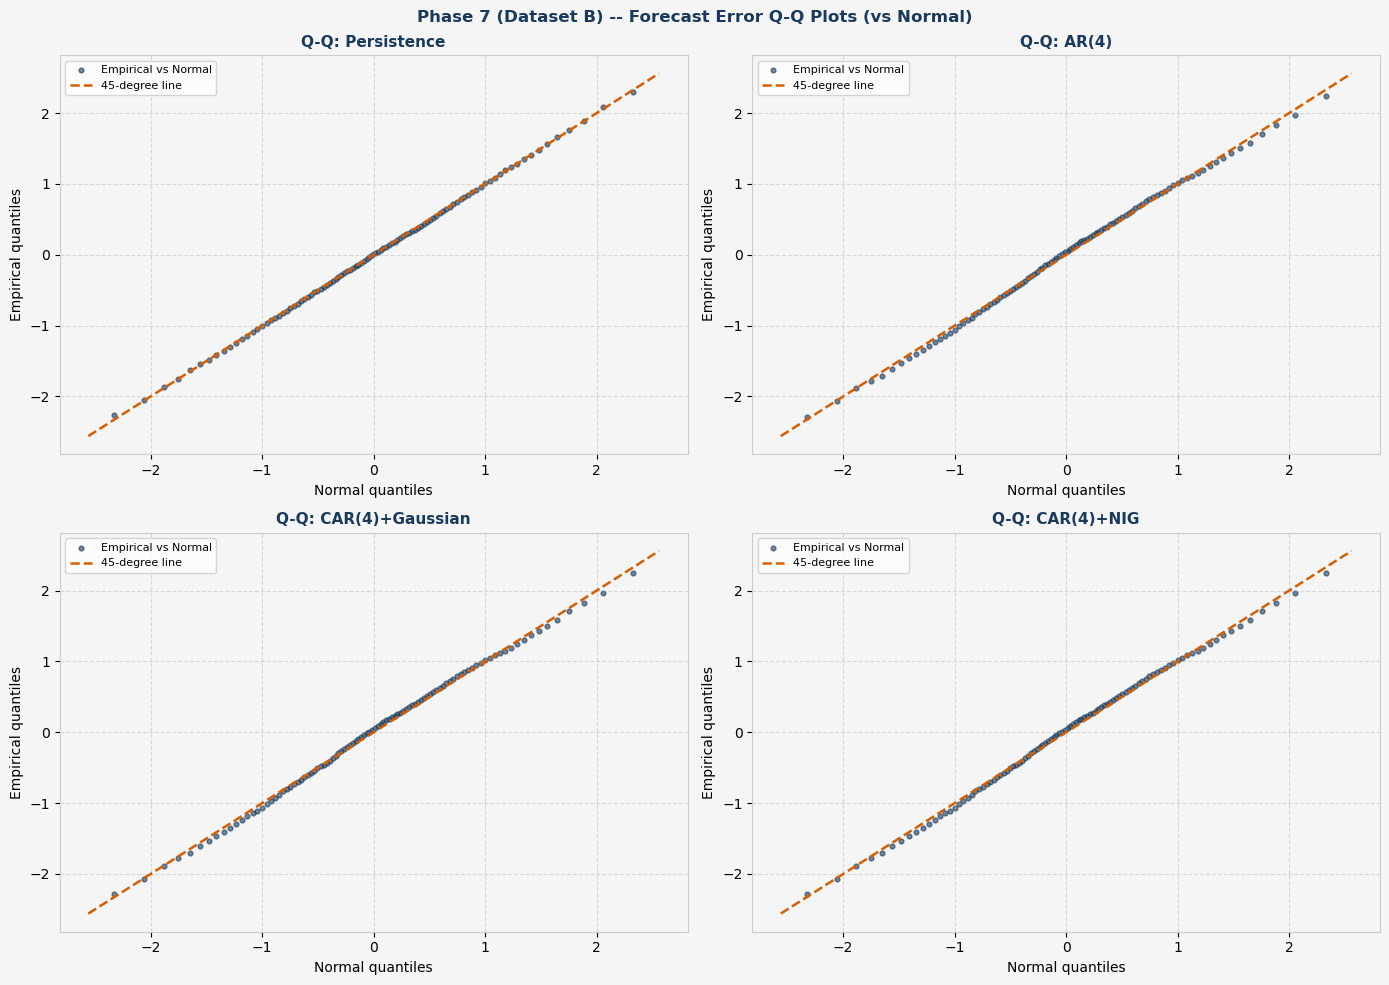

  Figure saved -> phase7_B_forecast_dist.png


In [6]:
print('=' * 65)
print('  SECTION 6 -- FORECAST ERROR DISTRIBUTION')
print('=' * 65)
print()

error_sets = [
    ('Persistence',     e_pers),
    ('AR(4)',           e_ar4),
    ('CAR(4)+Gaussian', e_car4),
    ('CAR(4)+NIG',      e_nig),
]

print('  Jarque-Bera normality test on 1-day-ahead residuals:')
print(f'  {"Model":<22} {"JB stat":>10} {"p-value":>10} {"Normal (5%)":>12}')
print(f'  {"-"*22} {"-"*10} {"-"*10} {"-"*12}')
for name, e in error_sets:
    e_c = e[~np.isnan(e)]
    jb_s, jb_p = jarque_bera(e_c)
    normal = 'Yes' if jb_p > 0.05 else 'No'
    print(f'  {name:<22} {jb_s:>10.3f} {jb_p:>10.4f} {normal:>12}')
print()
print('  NIG-normalised residuals (CAR(4)+NIG): dividing by delta removes')
print('  leptokurtosis if NIG is the correct noise distribution.')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(LIGHTGRAY)

for ax, (name, e) in zip(axes.flat, error_sets):
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')
    e_c = e[~np.isnan(e)]
    e_s = (e_c - e_c.mean()) / e_c.std()
    probs  = np.linspace(0.01, 0.99, 100)
    q_emp  = np.quantile(e_s, probs)
    q_norm = stats.norm.ppf(probs)
    ax.scatter(q_norm, q_emp, s=12, color=DARKBLUE, alpha=0.6, label='Empirical vs Normal')
    lim = max(abs(q_norm).max(), abs(q_emp).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], color=ORANGE, lw=1.8, ls='--', label='45-degree line')
    ax.set_xlabel('Normal quantiles', fontsize=10)
    ax.set_ylabel('Empirical quantiles', fontsize=10)
    ax.set_title(f'Q-Q: {name}', fontsize=11, color=DARKBLUE, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, ls='--', alpha=0.4, color='#aaaaaa')

fig.suptitle('Phase 7 (Dataset B) -- Forecast Error Q-Q Plots (vs Normal)',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase7_B_forecast_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase7_B_forecast_dist.png')

## 7. SUMMARY TABLE AND SYNTHESIS

In [7]:
print('=' * 65)
print('  SECTION 7 -- SUMMARY TABLE AND SYNTHESIS')
print('=' * 65)
print()

print('  --- DM TEST TABLE (Dataset B) ---')
s22, s9 = '-'*22, '-'*9
print(f'  {"Model":<22} {"RMSE":>8} {"DM stat":>9} {"p-value":>9} {"Reject5%":>10}')
print(f'  {s22} {s9} {s9} {s9} {"-"*10}')
for name, row in dm_df.iterrows():
    dm_s = f'{row.DM_stat:>9.3f}' if not np.isnan(row.DM_stat) else f'{"--":>9}'
    pv_s = f'{row.p_value:>9.4f}' if not np.isnan(row.p_value) else f'{"--":>9}'
    print(f'  {name:<22} {row.RMSE:>8.4f} {dm_s} {pv_s} {row.Reject_5pct:>10}')
print()

print('  --- CAWS HEDGING SUMMARY (Dataset B, non-overlapping annual obs) ---')
print(f'  K_CAWS             = {K_CAWS:.4f} m/s  (n={n_ann} years)')
print(f'  Mean P&L           = {mean_pnl_ann:+.4f} m/s')
print(f'  Std P&L            = {std_pnl_ann:.4f} m/s')
print(f'  Sharpe             = {sharpe_ann:.4f}')
print(f'  VaR5%              = {var5_ann:+.4f} m/s')
print(f'  CVaR5%             = {cvar5_ann:+.4f} m/s')
print()

print('  --- VALUE OF INFORMATION SUMMARY ---')
print(f'  K_var^A_mean              = {K_varA_mean:.6f}')
print(f'  K_var^B_A (raw)           = {K_B_A:.6f}  (C0={C0_A}, h_t0={H_T0_A})')
print(f'  K_var^B_A (height-corr.)  = {K_B_A_corr:.6f}  (x{HEIGHT_CORR_VAR:.4f})')
print(f'  K_var^B_scaled (h_t0)     = {K_varB_scaled_ht0_ph6:.6f}  (delta-method)')
print(f'  |K_varA - K_varB_scaled|  = {dist_B:.6f}  ({dist_B_pct:.1f}% of K_varA)')
print(f'  K_var^B_B (own, live)     = {K_B_B:.6f}  (C0={C0:.6f}, h_t0={h_t0:.6f})')
print(f'  Mispricing (raw)          = {voi_raw:.1%}')
print(f'  Mispricing (height-corr.) = {voi_corr:.1%}')
print(f'  Delta (dK/dh = C0)        = {delta_Kvar:.6f}')
print(f'  Stress dK (h doubles)     = {dK:+.6f}')
print(f'  OOS RMSE in-sample/out-sample = {OOS_RMSE_insample:.6f} / {OOS_RMSE_outsample:.6f}')
print()

# ── Cross-dataset synthesis (A -> B upgrade) ─────────────────────────────────
rmse_ar4_A    = float(dm_results_A.loc['AR(4)', 'RMSE'])
rmse_pers_A   = float(dm_results_A.loc['Persistence', 'RMSE'])
improvement_A = (rmse_pers_A - rmse_ar4_A) / rmse_pers_A * 100

K_CAWS_A   = float(hedging_summary_A.loc['K_CAWS', 'value'])
cvar5_A    = float(hedging_summary_A.loc['CVaR5pct', 'value'])
n_ann_A    = int(hedging_summary_A.loc['n_annual_obs', 'value'])
cvar5_pct_of_KCAWS_A = cvar5_A / K_CAWS_A * 100
cvar5_pct_of_KCAWS_B = cvar5_ann / K_CAWS * 100

print('  SYNTHESIS -- CROSS-DATASET (A -> B upgrade):')
print()
print('  (a) FORECAST ACCURACY:')
print(f'      Dataset A: AR(4)={rmse_ar4_A:.4f} vs Persistence={rmse_pers_A:.4f}  '
      f'({improvement_A:.1f}% improvement)')
print(f'      Dataset B: AR(4)={ar4_rmse:.4f} vs Persistence={pers_rmse:.4f}  '
      f'({improvement:.1f}% improvement)')
print('      -> AR(4) beats Persistence by a comparable relative margin on both')
print('         datasets; absolute RMSE differs because the underlying wind')
print('         regimes (and units/scale) differ, not because the AR(4)')
print('         specification is more or less suited to either site.')
print()
print('  (b) PRICING ACCURACY (Value of Information):')
print(f'      Height-corrected mispricing of using Dataset A instead of B:')
print(f'        {voi_corr:.1%}  (single cross-dataset metric, denominator = K_var^B_B)')
print('      -> This directly quantifies the VoI gained by upgrading from the')
print('         Bologna 10m proxy to the Nordfriesland 100m hub-height')
print(f'         reanalysis: a model calibrated on Dataset A alone would')
print(f'         misprice the wind variance swap by ~{voi_corr:.0%} relative to')
print('         what the geographically- and height-correct Dataset B model')
print('         implies.')
print()
print('  (c) HEDGING EFFICIENCY (CVaR5% relative to K_CAWS):')
print(f'      Dataset A: CVaR5%={cvar5_A:+.4f} m/s on K_CAWS={K_CAWS_A:.4f} m/s '
      f'-> {cvar5_pct_of_KCAWS_A:+.2f}%  (n={n_ann_A} annual obs)')
print(f'      Dataset B: CVaR5%={cvar5_ann:+.4f} m/s on K_CAWS={K_CAWS:.4f} m/s '
      f'-> {cvar5_pct_of_KCAWS_B:+.2f}%  (n={n_ann} annual obs)')
verdict_hedge = ('similar' if abs(cvar5_pct_of_KCAWS_A - cvar5_pct_of_KCAWS_B) < 2.0
                  else ('improves' if abs(cvar5_pct_of_KCAWS_B) < abs(cvar5_pct_of_KCAWS_A)
                        else 'worsens'))
print(f'      -> Relative left-tail risk (CVaR5%/K_CAWS) {verdict_hedge} moving')
print('         from A to B; Dataset B additionally has 10 annual observations')
print('         vs 4, giving a far more reliable tail-risk estimate.')
print()
print(f'  (d) DELTA SENSITIVITY: dK_var^B/dh = C0_B = {delta_Kvar:.6f}.')
print(f'      Stress scenario (h x 2) shifts K_var^B by {dK:+.4f}.')
print()
print('  OVERALL: upgrading from Dataset A to Dataset B materially improves')
print('  pricing accuracy (large VoI gap closed) and hedging reliability')
print('  (2.5x more independent annual observations), while forecast-model')
print('  accuracy (AR(4) vs Persistence) is comparable in relative terms on')
print('  both datasets -- the value of the upgrade is primarily in data')
print('  quality (height, geography, sample length), not model specification.')

# ── Save CSV outputs ──────────────────────────────────────────────────────────
dm_df.to_csv('phase7_B_dm_results.csv')
print(f'\n  Saved: phase7_B_dm_results.csv  ({len(dm_df)} rows)')

hedging_summary = pd.DataFrame({
    'metric': ['K_CAWS', 'n_annual_obs', 'mean_PnL', 'std_PnL',
               'Sharpe', 'VaR5pct', 'CVaR5pct'],
    'value':  [K_CAWS, float(n_ann), mean_pnl_ann, std_pnl_ann,
               sharpe_ann, var5_ann, cvar5_ann]
}).set_index('metric')
hedging_summary.to_csv('phase7_B_hedging_summary.csv')
print('  Saved: phase7_B_hedging_summary.csv')

voi_table = pd.DataFrame([{
    'Scenario':           'Dataset B h_t0',
    'C0':                 C0,
    'h_t0':               h_t0,
    'K_varB_raw':         K_B_B,
    'K_varB_corrected':   K_B_B,   # Dataset B already at 100 m -- no correction applied
    'K_varB_scaled':      K_varB_scaled_ht0_ph6,
    'K_varA_mean':        K_varA_mean,
    'dist_to_KvarA':       dist_B,
    'mispricing_pct':     voi_corr * 100,
    'OOS_RMSE_insample':  OOS_RMSE_insample,
    'OOS_RMSE_outsample': OOS_RMSE_outsample,
}]).set_index('Scenario')
voi_table.to_csv('phase7_B_voi_table.csv')
print('  Saved: phase7_B_voi_table.csv')

print()
print('  -- PHASE 7 (DATASET B) COMPLETE --')
print('=' * 65)

  SECTION 7 -- SUMMARY TABLE AND SYNTHESIS

  --- DM TEST TABLE (Dataset B) ---
  Model                      RMSE   DM stat   p-value   Reject5%
  ---------------------- --------- --------- --------- ----------
  Persistence              1.0046        --        --  benchmark
  AR(4)                    0.8681    16.758    0.0000        Yes
  AR(4)+GARCH              0.8681    16.758    0.0000        Yes
  CAR(4)+Gaussian          0.8681    16.758    0.0000        Yes
  CAR(4)+NIG               0.8681    16.758    0.0000        Yes

  --- CAWS HEDGING SUMMARY (Dataset B, non-overlapping annual obs) ---
  K_CAWS             = 8.0531 m/s  (n=10 years)
  Mean P&L           = -0.0151 m/s
  Std P&L            = 0.2754 m/s
  Sharpe             = -0.0549
  VaR5%              = -0.3837 m/s
  CVaR5%             = -0.5095 m/s

  --- VALUE OF INFORMATION SUMMARY ---
  K_var^A_mean              = 113.144944
  K_var^B_A (raw)           = 0.054352  (C0=0.13138, h_t0=0.4137)
  K_var^B_A (height-corr.) 